# Recommendation Model Development

This notebook covers model development, hyperparameter tuning, evaluation, and deployment setup for the Alternating Least Squares (ALS) model, with a Popularity baseline for comparison.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import implicit
import pickle
import json
import itertools
import os
from implicit.evaluation import ranking_metrics_at_k

os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../models", exist_ok=True)

c:\Users\QuocHuy\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Phase 1: Model Development
### Load data and build train/test sparse matrices

We use the `train.csv` / `test.csv` produced during feature engineering (user, item, weight), and the full `interaction_matrix.npz` only to get the correct (n_users, n_items) shape so the train/test matrices align with the saved encoders.

In [2]:
# Reference shape from the full interaction matrix (all users/items seen during encoding)
interaction_matrix = sparse.load_npz("../data/processed/interaction_matrix.npz")
n_users, n_items = interaction_matrix.shape
print(f"Full matrix shape (users x items): {n_users} x {n_items}")

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))

Full matrix shape (users x items): 1407579 x 235061
Train interactions: 1716140
Test interactions: 429036


In [3]:
def build_matrix(df, shape):
    return sparse.csr_matrix(
        (df["weight"], (df["user"], df["item"])),
        shape=shape
    )

train_matrix = build_matrix(train_df, (n_users, n_items))
test_matrix = build_matrix(test_df, (n_users, n_items))

print("train_matrix:", train_matrix.shape, train_matrix.nnz, "non-zero entries")
print("test_matrix: ", test_matrix.shape, test_matrix.nnz, "non-zero entries")

train_matrix: (1407579, 235061) 1716140 non-zero entries
test_matrix:  (1407579, 235061) 429036 non-zero entries


### Train baseline ALS model

In [4]:
factors = 50
regularization = 0.01
iterations = 15

print(f"Training baseline ALS model (factors={factors}, reg={regularization}, iter={iterations})...")
baseline_model = implicit.als.AlternatingLeastSquares(
    factors=factors,
    regularization=regularization,
    iterations=iterations,
    random_state=42
)

# Fit directly on the user x item matrix -- no transpose
baseline_model.fit(train_matrix)
print("Baseline model training complete.")

Training baseline ALS model (factors=50, reg=0.01, iter=15)...


c:\Users\QuocHuy\AppData\Local\Programs\Python\Python311\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 15/15 [00:27<00:00,  1.83s/it]

Baseline model training complete.


In [5]:
# Quick sanity check on the baseline model using implicit's built-in metrics
baseline_metrics = ranking_metrics_at_k(
    baseline_model, train_matrix, test_matrix, K=10, show_progress=False
)
print("Baseline ALS (untuned) @K=10:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline ALS (untuned) @K=10:
  precision: 0.0208
  map: 0.0092
  ndcg: 0.0119
  auc: 0.5089


## Custom Recall@K

`implicit.evaluation` provides `precision_at_k`, `ndcg_at_k`, `mean_average_precision_at_k`, `AUC_at_k`, and the combined `ranking_metrics_at_k` — but no Recall@K, which the project rubric requires. We add a lightweight evaluator (with sampling, since looping in Python over ~1.4M users would be slow) that computes Precision@K, Recall@K, and NDCG@K consistently for **any** recommender function, so ALS and the Popularity baseline are judged the same way.

In [6]:
def ndcg_score(recommended, relevant, k):
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_recommendations(recommend_fn, test_matrix, k=10, sample_size=5000, random_state=42):
    """
    recommend_fn(user_id) -> list of up to k recommended item ids
    (already filtering out items the user interacted with in training).
    """
    rng = np.random.RandomState(random_state)
    test_users = np.where(test_matrix.getnnz(axis=1) > 0)[0]
    if len(test_users) > sample_size:
        test_users = rng.choice(test_users, size=sample_size, replace=False)

    precisions, recalls, ndcgs = [], [], []
    for user in test_users:
        relevant = set(test_matrix[user].indices)
        if not relevant:
            continue
        recommended = recommend_fn(user)
        hits = len(set(recommended) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        ndcgs.append(ndcg_score(recommended, relevant, k))

    return {
        "precision": float(np.mean(precisions)) if precisions else 0.0,
        "recall": float(np.mean(recalls)) if recalls else 0.0,
        "ndcg": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "users_evaluated": len(precisions),
    }

## Phase 2: Hyperparameter Tuning

Grid search over `factors`, `regularization`, and `iterations`. Each combination is trained on `train_matrix` and scored on `test_matrix` using `ranking_metrics_at_k` (fast, implemented in Cython) so the full test set can be used for model selection, rather than a sample.

In [7]:
def tune_hyperparameters(train_matrix, test_matrix, k=10):
    factors_grid = [20, 50, 100]
    reg_grid = [0.01, 0.05, 0.1]
    iter_grid = [10, 20]

    results = []
    best_ndcg = -1
    best_params = {}

    print("Starting hyperparameter tuning...")
    for f, r, i in itertools.product(factors_grid, reg_grid, iter_grid):
        temp_model = implicit.als.AlternatingLeastSquares(
            factors=f, regularization=r, iterations=i, random_state=42
        )
        temp_model.fit(train_matrix, show_progress=False)

        metrics = ranking_metrics_at_k(
            temp_model, train_matrix, test_matrix, K=k, show_progress=False
        )
        metrics.update({"factors": f, "regularization": r, "iterations": i})
        results.append(metrics)

        print(f"Params (F:{f}, R:{r}, I:{i}) -> "
              f"Precision@{k}: {metrics['precision']:.4f}  NDCG@{k}: {metrics['ndcg']:.4f}")

        if metrics["ndcg"] > best_ndcg:
            best_ndcg = metrics["ndcg"]
            best_params = {"factors": f, "regularization": r, "iterations": i}

    print(f"\nBest Parameters: {best_params} with NDCG@{k}: {best_ndcg:.4f}")
    return best_params, pd.DataFrame(results)


best_params, tuning_results = tune_hyperparameters(train_matrix, test_matrix, k=10)

Starting hyperparameter tuning...
Params (F:20, R:0.01, I:10) -> Precision@10: 0.0119  NDCG@10: 0.0064
Params (F:20, R:0.01, I:20) -> Precision@10: 0.0122  NDCG@10: 0.0066
Params (F:20, R:0.05, I:10) -> Precision@10: 0.0119  NDCG@10: 0.0064
Params (F:20, R:0.05, I:20) -> Precision@10: 0.0122  NDCG@10: 0.0066
Params (F:20, R:0.1, I:10) -> Precision@10: 0.0119  NDCG@10: 0.0064
Params (F:20, R:0.1, I:20) -> Precision@10: 0.0122  NDCG@10: 0.0066
Params (F:50, R:0.01, I:10) -> Precision@10: 0.0205  NDCG@10: 0.0117
Params (F:50, R:0.01, I:20) -> Precision@10: 0.0209  NDCG@10: 0.0119
Params (F:50, R:0.05, I:10) -> Precision@10: 0.0205  NDCG@10: 0.0117
Params (F:50, R:0.05, I:20) -> Precision@10: 0.0209  NDCG@10: 0.0119
Params (F:50, R:0.1, I:10) -> Precision@10: 0.0205  NDCG@10: 0.0117
Params (F:50, R:0.1, I:20) -> Precision@10: 0.0209  NDCG@10: 0.0119
Params (F:100, R:0.01, I:10) -> Precision@10: 0.0295  NDCG@10: 0.0171
Params (F:100, R:0.01, I:20) -> Precision@10: 0.0300  NDCG@10: 0.0172
Pa

In [8]:
tuning_results = tuning_results.sort_values("ndcg", ascending=False).reset_index(drop=True)
tuning_results.to_csv("../results/metrics/als_tuning_results.csv", index=False)
tuning_results.head(10)

,precision,map,ndcg,auc,factors,regularization,iterations
0,0.030035,0.013428,0.017227,0.512971,100,0.05,20
1,0.030015,0.013418,0.017216,0.512965,100,0.01,20
2,0.030013,0.013417,0.017213,0.512961,100,0.10,20
3,0.029472,0.013400,0.017098,0.512762,100,0.10,10
4,0.029496,0.013385,0.017092,0.512775,100,0.01,10
5,0.029486,0.013378,0.017086,0.512772,100,0.05,10
6,0.020938,0.009220,0.011867,0.508927,50,0.01,20
7,0.020926,0.009221,0.011866,0.508925,50,0.05,20
8,0.020921,0.009221,0.011862,0.508915,50,0.10,20
9,0.020544,0.009117,0.011714,0.508805,50,0.01,10


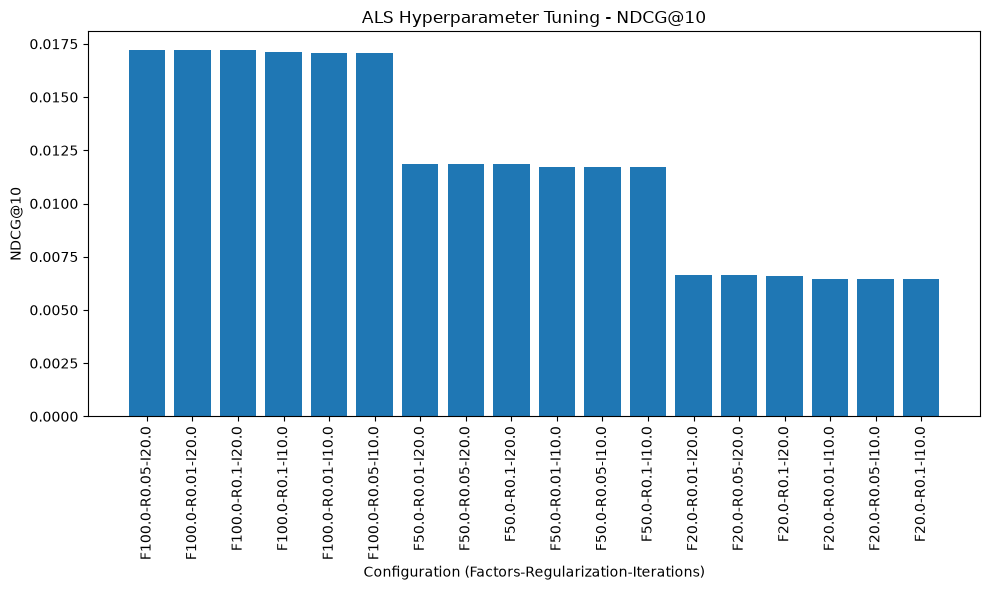

In [9]:
# Chart: NDCG@10 across hyperparameter combinations
plt.figure(figsize=(10, 6))
labels = tuning_results.apply(lambda row: f"F{row.factors}-R{row.regularization}-I{row.iterations}", axis=1)
plt.bar(labels, tuning_results["ndcg"])
plt.xticks(rotation=90)
plt.title("ALS Hyperparameter Tuning - NDCG@10")
plt.xlabel("Configuration (Factors-Regularization-Iterations)")
plt.ylabel("NDCG@10")
plt.tight_layout()
plt.savefig("../results/figures/als_tuning_ndcg.png")
plt.show()

## Phase 3: Evaluation

Train the best model (from tuning) on `train_matrix`, then report Precision@K, Recall@K, and NDCG@K on `test_matrix` using the sampled evaluator defined above. We also build a simple Popularity baseline for comparison, as required by the report's evaluation section.

In [10]:
print(f"Training best ALS model with {best_params} ...")
best_model = implicit.als.AlternatingLeastSquares(
    factors=best_params["factors"],
    regularization=best_params["regularization"],
    iterations=best_params["iterations"],
    random_state=42
)
best_model.fit(train_matrix)
print("Best model training complete.")

Training best ALS model with {'factors': 100, 'regularization': 0.05, 'iterations': 20} ...


100%|██████████| 20/20 [00:48<00:00,  2.41s/it]

Best model training complete.


In [11]:
K = 10

def als_recommend_fn(user):
    ids, _ = best_model.recommend(
        user, train_matrix[user], N=K, filter_already_liked_items=True
    )
    return list(ids)

als_metrics = evaluate_recommendations(als_recommend_fn, test_matrix, k=K, sample_size=5000)
print(f"ALS (tuned) @K={K}:", als_metrics)

ALS (tuned) @K=10: {'precision': 0.00318, 'recall': 0.024121706361480564, 'ndcg': 0.015762705440365232, 'users_evaluated': 5000}


In [12]:
# Popularity baseline: rank items by total interaction weight in the training set
item_popularity = np.asarray(train_matrix.sum(axis=0)).flatten()
popular_items_sorted = np.argsort(-item_popularity)

def popularity_recommend_fn(user):
    seen = set(train_matrix[user].indices)
    recs = []
    for item in popular_items_sorted:
        if item not in seen:
            recs.append(item)
            if len(recs) == K:
                break
    return recs

popularity_metrics = evaluate_recommendations(popularity_recommend_fn, test_matrix, k=K, sample_size=5000)
print(f"Popularity baseline @K={K}:", popularity_metrics)

Popularity baseline @K=10: {'precision': 0.0009199999999999999, 'recall': 0.008601092896174863, 'ndcg': 0.004386345459610088, 'users_evaluated': 5000}


In [13]:
comparison = pd.DataFrame([
    {"model": "Popularity Baseline", **popularity_metrics},
    {"model": "ALS (tuned)", **als_metrics},
])
comparison.to_csv("../results/metrics/model_comparison.csv", index=False)
comparison

,model,precision,recall,ndcg,users_evaluated
0,Popularity Baseline,0.00092,0.008601,0.004386,5000
1,ALS (tuned),0.00318,0.024122,0.015763,5000


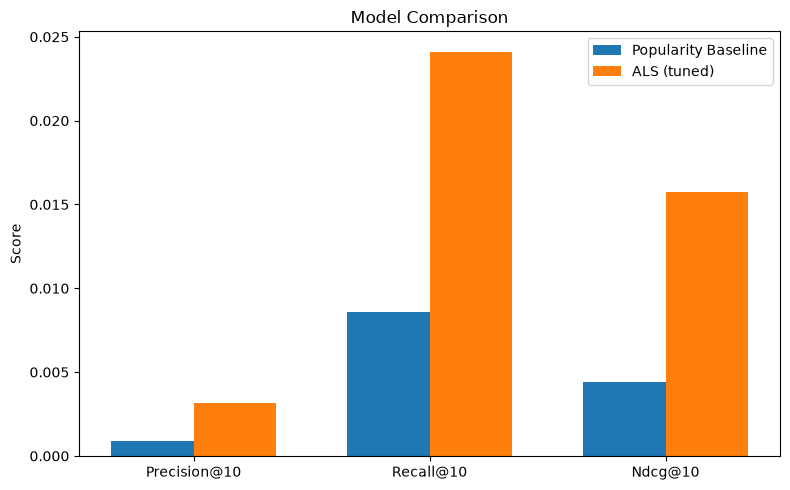

In [14]:
# Chart: model comparison
metrics_to_plot = ["precision", "recall", "ndcg"]
x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison.loc[0, metrics_to_plot], width, label="Popularity Baseline")
plt.bar(x + width/2, comparison.loc[1, metrics_to_plot], width, label="ALS (tuned)")
plt.xticks(x, [f"{m.capitalize()}@{K}" for m in metrics_to_plot])
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png")
plt.show()

## Phase 4: Deployment

For deployment we retrain a final model on the **full** interaction history (train + test combined) using the tuned hyperparameters[cite: 3]. Then, we bundle the trained model, the interaction matrix, and the encoders into a single `Recommender` wrapper object to be pickled for the Django backend[cite: 2].

The `Recommender` class is in `recommender_wrapper.py` (not defined inline), so both this notebook and the Django app can `from recommender_wrapper import Recommender` before unpickling `recommender.pkl` -- pickle needs the class definition importable at load time, it doesn't store the code itself.

In [15]:
print(f"Training final production ALS model on full data with {best_params} ...")
final_model = implicit.als.AlternatingLeastSquares(
    factors=best_params["factors"],
    regularization=best_params["regularization"],
    iterations=best_params["iterations"],
    random_state=42
)
final_model.fit(interaction_matrix)
print("Final production model training complete.")

Training final production ALS model on full data with {'factors': 100, 'regularization': 0.05, 'iterations': 20} ...


100%|██████████| 20/20 [00:52<00:00,  2.63s/it]

Final production model training complete.


In [16]:
from recommender_wrapper import Recommender

# Load the encoders
with open("../data/processed/user_encoder.pkl", "rb") as f:
    user_encoder = pickle.load(f)

with open("../data/processed/item_encoder.pkl", "rb") as f:
    item_encoder = pickle.load(f)

# Bundle the trained model, interaction matrix, and encoders into one deployable object
wrapper = Recommender(
    model=final_model,
    interaction_matrix=interaction_matrix,
    user_encoder=user_encoder,
    item_encoder=item_encoder
)

# Save the wrapper object and hyperparameters
model_path = "../models/recommender.pkl"
with open(model_path, "wb") as f:
    pickle.dump(wrapper, f)

with open("../models/best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

print(f"Deployment wrapper successfully saved to {model_path}")
print(f"Best hyperparameters saved to ../models/best_params.json: {best_params}")

Deployment wrapper successfully saved to ../models/recommender.pkl
Best hyperparameters saved to ../models/best_params.json: {'factors': 100, 'regularization': 0.05, 'iterations': 20}


In [17]:
with open("../data/processed/user_encoder.pkl", "rb") as f:
    user_encoder = pickle.load(f)

print("Total known visitor_ids:", len(user_encoder.classes_))
print("All visitor_ids:", user_encoder.classes_[:])

Total known visitor_ids: 1407579
All visitor_ids: [      1       2       3 ... 1407577 1407578 1407579]


In [18]:
# Test the deployment wrapper for a known visitor
test_id = 257597
print(f"\nTesting recommend() function via the saved wrapper for visitor_id {test_id}:")

with open("../models/recommender.pkl", "rb") as f:
    loaded_wrapper = pickle.load(f)

result = loaded_wrapper.recommend(
    visitor_id=test_id,
    top_k=5
)

print(result)


Testing recommend() function via the saved wrapper for visitor_id 257597:
[{'item_id': 175356, 'score': 0.006514786276966333}, {'item_id': 16813, 'score': 0.006434028502553701}, {'item_id': 280375, 'score': 0.006328956224024296}, {'item_id': 391289, 'score': 0.005849290639162064}, {'item_id': 152433, 'score': 0.004564913455396891}]
